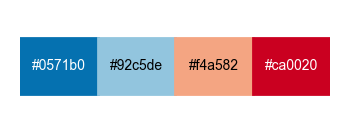

In [33]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [34]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

# input and output

In [35]:
IBDMDB_file = '../../Data/IBDMDB/Data1_metadata_from_ibdmdb.xlsx'
HGM_file = '../../Data/IBDMDB/taxonomic_profiles.tsv'

In [36]:
HGM_data = pd.read_csv(HGM_file,sep='\t')
HGM_data.head()

,#SampleID,CSM5FZ4M,CSM5MCUO,CSM5MCVL,CSM5MCVN,CSM5MCW6,CSM5MCWC,CSM5MCWE,CSM5MCWG,CSM5MCWQ,...,CSM5MCVJ_P,CSM5MCWI_P,MSM5LLHA_P,HSM5MD59_P,HSM5MD8N_P,CSM6J2H9_P,HSM5MD4A_P,CSM5MCUW_P,ESM5MEBA_P,HSM5FZC2_P
0,k__Archaea,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
1,k__Archaea|p__Euryarchaeota,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
2,k__Archaea|p__Euryarchaeota|c__Methanobacteria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
3,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0
4,k__Archaea|p__Euryarchaeota|c__Methanobacteria...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000093,0.0,0.0


In [37]:
IBDMDB_data = pd.read_excel(IBDMDB_file,sheet_name = 'Person_Sample')
IBDMDB_data.head(3)

,Project,External ID,Participant ID,site_sub_coll,data_type,week_num,date_of_receipt,interval_days,visit_num,IntervalName,...,Age at diagnosis,Education Level,Occupation,consent_age,diagnosis,General wellbeing,Abdominal pain,baseline_montreal_location,race,sex
0,G79889,CSM5FZ3N_P,C3001,C3001C1,metagenomics,0,2014-03-14,0,4,Stool Collection #1,...,28.0,Bachelor's degree,Paid,43,CD,Slightly below par,Mild,L3,White,Female
1,G79894,CSM5FZ3R_P,C3001,C3001C2,metagenomics,2,2014-03-28,14,5,Stool Collection #2,...,28.0,Bachelor's degree,Paid,43,CD,Very Well,Mild,L3,White,Female
2,G79903,CSM5YRY7_P,C3001,C3001C3,metagenomics,4,2014-04-15,18,6,Stool Collection #3,...,28.0,Bachelor's degree,Paid,43,CD,Poor,Mild,L3,White,Female


In [38]:
def get_sampleID_by_peopleID(peopleID,IBDMDB_data):
    tmp_df = IBDMDB_data[IBDMDB_data['Participant ID']==peopleID]
    return tmp_df['External ID'].to_list()

In [39]:
def deal_sampleinfo_level(HGM_data, level='f__'):
    HGM_data_levellist = HGM_data['#SampleID'].to_list()
    # 返回索引和level
    HGM_data_levellist = [(i, x.split('|')[4].replace(level, '')) 
                         for i, x in enumerate(HGM_data_levellist) 
                         if len(x.split('|')) == 5]
    return HGM_data_levellist

# 调用函数
HGM_data_levellist = deal_sampleinfo_level(HGM_data, level='f__')
HGM_data_levellist

[(4, 'Methanobacteriaceae'),
 (13, 'Acidobacteriaceae'),
 (21, 'Actinomycetaceae'),
 (40, 'Brevibacteriaceae'),
 (45, 'Corynebacteriaceae'),
 (57, 'Dermabacteraceae'),
 (60, 'Microbacteriaceae'),
 (63, 'Micrococcaceae'),
 (75, 'Nocardioidaceae'),
 (78, 'Propionibacteriaceae'),
 (86, 'Bifidobacteriaceae'),
 (121, 'Coriobacteriaceae'),
 (161, 'Bacteroidetes_noname'),
 (169, 'Bacteroidaceae'),
 (246, 'Bacteroidales_noname'),
 (250, 'Porphyromonadaceae'),
 (300, 'Prevotellaceae'),
 (356, 'Rikenellaceae'),
 (377, 'Flavobacteriaceae'),
 (382, 'Sphingobacteriaceae'),
 (388, 'Chlorobiaceae'),
 (395, 'Oscillatoriales_noname'),
 (401, 'Deinococcaceae'),
 (407, 'Bacillaceae'),
 (413, 'Bacillales_noname'),
 (422, 'Staphylococcaceae'),
 (433, 'Aerococcaceae'),
 (444, 'Carnobacteriaceae'),
 (451, 'Enterococcaceae'),
 (479, 'Lactobacillaceae'),
 (531, 'Leuconostocaceae'),
 (544, 'Streptococcaceae'),
 (603, 'Clostridiaceae'),
 (660, 'Clostridiales_Family_XIII_Incertae_Sedis'),
 (665, 'Clostridiales_Fa

In [40]:
def deal_sampleinfo_level(HGM_data, level='f__'):
    HGM_data_levellist = HGM_data['#SampleID'].to_list()
    # 返回索引和level
    HGM_data_levellist = [(i, x.split('|')[4].replace(level, '')) 
                         for i, x in enumerate(HGM_data_levellist) 
                         if len(x.split('|')) == 5]
    return HGM_data_levellist

# 调用函数
HGM_data_levellist = deal_sampleinfo_level(HGM_data, level='f__')

def get_sampleID_abundance(sampleID,HGM_data,HGM_data_levellist):
    sampleID_abundance = HGM_data[sampleID].to_list()
    abundance_dict = {}
    for index, level in HGM_data_levellist:   # ✅ 不要用 .items()
        if level not in abundance_dict:
            abundance_dict[level] = sampleID_abundance[index]
        else:
            abundance_dict[level] += sampleID_abundance[index]
    abundance_dict = {k:v for k,v in abundance_dict.items() if v>0}
    
    return abundance_dict

sampleID = 'CSM5FZ4M'
get_sampleID_abundance(sampleID,HGM_data,HGM_data_levellist)

{'Propionibacteriaceae': 0.0001691,
 'Coriobacteriaceae': 0.000145,
 'Bacteroidaceae': 0.687465,
 'Porphyromonadaceae': 0.0796653,
 'Rikenellaceae': 0.062968,
 'Clostridiaceae': 0.0009454,
 'Clostridiales_noname': 0.0001955,
 'Eubacteriaceae': 0.0043921,
 'Lachnospiraceae': 0.010232,
 'Oscillospiraceae': 0.0041547,
 'Ruminococcaceae': 0.116388,
 'Erysipelotrichaceae': 0.0003619,
 'Acidaminococcaceae': 0.0311922,
 'Veillonellaceae': 0.0001278,
 'Desulfovibrionaceae': 0.000523,
 'Enterobacteriaceae': 0.0010136,
 'Potyviridae': 6.19e-05}

In [41]:
import math
def calculate_sampleID_score(family_list, abund_dict, enzyme_counts_dict):
    score = 0
    for family in family_list:
        abund = abund_dict.get(family, 0)
        enzyme_count = enzyme_counts_dict.get(family, 0)
        score += (abund ** 1) * (enzyme_count ** 3)
    return score

In [42]:
strain_counts = {'Enterococcaceae': 471,
 'Streptococcaceae': 599,
 'Turicibacteraceae': 0,
 'Enterobacteriaceae': 1403,
 'Alcaligenaceae': 2,
 'Veillonellaceae': 3,
 'Peptostreptococcaceae': 17,
 'Porphyromonadaceae': 2,
 'Erysipelotrichaceae': 2,
 'Clostridiaceae': 40,
 'Bifidobacteriaceae': 21,
 'Rikenellaceae': 0,
 'Bacteroidaceae': 50,
 'Ruminococcaceae': 0,
 'Lachnospiraceae': 26}

# 5-ASA   2.3.1.5

In [43]:
import json
with open('../../Result/ec_strain_enzymecounts_top4_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

print(enzyme_eccounts_dict)


enzyme_counts_dict = enzyme_eccounts_dict['2.3.1.5']
enzyme_counts_dict

{'7.2.2.21': {'Bifidobacteriaceae': 43, 'Bacteroidaceae': 78, 'Porphyromonadaceae': 3, 'Rikenellaceae': 13, 'Enterococcaceae': 1748, 'Streptococcaceae': 1122, 'Turicibacteraceae': 3, 'Clostridiaceae': 57, 'Lachnospiraceae': 65, 'Peptostreptococcaceae': 36, 'Ruminococcaceae': 3, 'Veillonellaceae': 9, 'Erysipelotrichaceae': 36, 'Alcaligenaceae': 12, 'Enterobacteriaceae': 3169}, '7.1.1.2': {'Bifidobacteriaceae': 75, 'Bacteroidaceae': 302, 'Porphyromonadaceae': 6, 'Rikenellaceae': 22, 'Enterococcaceae': 3801, 'Streptococcaceae': 2721, 'Turicibacteraceae': 30, 'Clostridiaceae': 327, 'Lachnospiraceae': 296, 'Peptostreptococcaceae': 110, 'Ruminococcaceae': 9, 'Veillonellaceae': 26, 'Erysipelotrichaceae': 157, 'Alcaligenaceae': 33, 'Enterobacteriaceae': 30305}, '2.7.1.202': {'Bifidobacteriaceae': 81, 'Bacteroidaceae': 234, 'Porphyromonadaceae': 6, 'Rikenellaceae': 26, 'Enterococcaceae': 4301, 'Streptococcaceae': 4788, 'Turicibacteraceae': 35, 'Clostridiaceae': 495, 'Lachnospiraceae': 379, 'Pep

{'Bifidobacteriaceae': 11,
 'Bacteroidaceae': 153,
 'Porphyromonadaceae': 8,
 'Rikenellaceae': 29,
 'Enterococcaceae': 31,
 'Streptococcaceae': 97,
 'Turicibacteraceae': 0,
 'Clostridiaceae': 1,
 'Lachnospiraceae': 1,
 'Peptostreptococcaceae': 16,
 'Ruminococcaceae': 2,
 'Veillonellaceae': 0,
 'Erysipelotrichaceae': 13,
 'Alcaligenaceae': 2,
 'Enterobacteriaceae': 13}

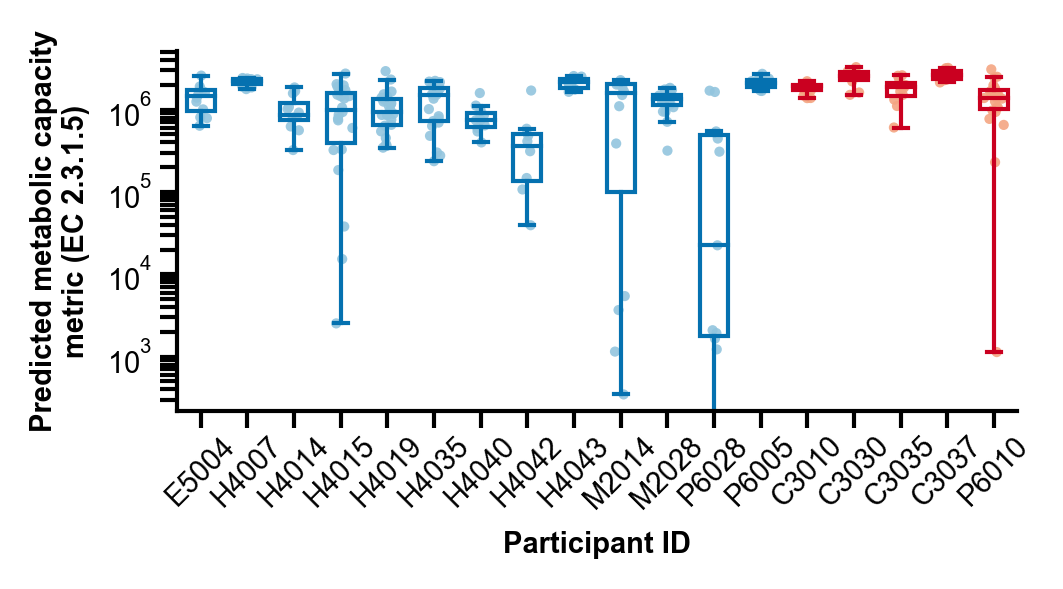

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

peopleID_list = ['E5004','H4007','H4014','H4015','H4019','H4035','H4040','H4042','H4043',
                 'M2014','M2028','P6028','P6005','C3010','C3030','C3035','C3037','P6010']#'C3017',
height_data_single = {
    'Streptococcaceae': 3.1,
    'Turicibacteraceae': 3.1,
    'Enterobacteriaceae': 3.1,
    'Alcaligenaceae': 3.4,
    'Veillonellaceae': 3.8,
    'Peptostreptococcaceae': 4.1,
    'Porphyromonadaceae': 4.2,
    'Erysipelotrichaceae': 4.5,
    'Clostridiaceae': 4.5,
    'Bifidobacteriaceae': 5.0,
    'Rikenellaceae': 5.3,
    'Bacteroidaceae': 10.0,
    'Ruminococcaceae': 32.0,
    'Lachnospiraceae': 34.0
}
result ={}
for peopleID in peopleID_list:
    result[peopleID] = [] 
    # print('========', peopleID, '========')
    sampleID_list = get_sampleID_by_peopleID(peopleID, IBDMDB_data)
    all_data = {}
    key_counter = Counter()

    for sampleID in sampleID_list:
        abund_dict = get_sampleID_abundance(sampleID, HGM_data, HGM_data_levellist)
        score = calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)
        # print(peopleID,sampleID,score,abund_dict)
        result[peopleID].append(score)
        
import matplotlib.pyplot as plt
import numpy as np

# ===== 数据 =====
data = result

people_ids = list(data.keys())      # 横坐标标签
result_value = list(data.values())        # 每个样本的数值列表
positions = np.arange(len(result_value)) + 0.5  # 箱子位置

# ===== 画布 & 样式 =====
plt.figure(figsize=(3.5, 1.5), dpi=300)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.2, 0.2, 0.8, 0.8]) 
# ===== 调色板 =====
colors = ['#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', 
                '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', 
                '#0571b0','#ca0020', '#ca0020', '#ca0020', '#ca0020', '#ca0020']  # 可扩展调色板
group_colors = ['#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', 
                '#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', 
                '#92c5de','#f4a582', '#f4a582', '#f4a582', '#f4a582', '#f4a582']

# ===== 绘制箱线图 =====
box = plt.boxplot(result_value, positions=positions, widths=0.6,
                  patch_artist=True, showfliers=False)

# ===== box =====
for i, patch in enumerate(box['boxes']):
    color = colors[i]
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(1)

# ===== whiskers =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['whiskers'][2*i].set_color(color)
    box['whiskers'][2*i+1].set_color(color)
    box['whiskers'][2*i].set_linewidth(1)
    box['whiskers'][2*i+1].set_linewidth(1)

# ===== caps =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['caps'][2*i].set_color(color)
    box['caps'][2*i+1].set_color(color)
    box['caps'][2*i].set_linewidth(1)
    box['caps'][2*i+1].set_linewidth(1)

# ===== median =====（每组1条）
for i, median in enumerate(box['medians']):
    color = colors[i]
    median.set_color(color)
    median.set_linewidth(1)

# ===== 绘制散点（stripplot效果） =====
for i, group in enumerate(result_value):
    x_jittered = positions[i] + np.random.normal(0, 0.08, size=len(group))
    plt.scatter(x_jittered, group,
                color=group_colors[i % len(group_colors)],
                edgecolors='none', s=6, zorder=-3, alpha=0.9)
# y轴对数
plt.yscale("log")
# import matplotlib.ticker as ticker
# plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
# ===== 坐标轴 =====
plt.xticks(positions, people_ids, fontsize=7, rotation=45)
plt.xlabel("Participant ID", fontsize=7, fontweight='bold')
plt.ylabel("Predicted metabolic capacity\nmetric (EC 2.3.1.5)", fontsize=7, fontweight='bold')
plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)
# plt.ylim(1e6, 5e6)

plt.show()


Mann–Whitney U test p-value: 5.6990e-08


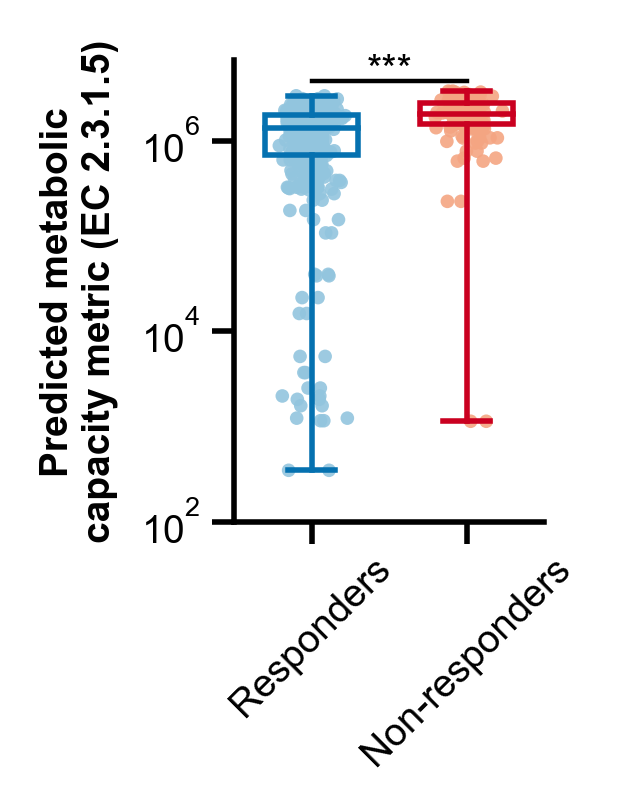

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu  # 也可用 ttest_ind

# ===== 数据 =====
data = result  # 原始 result = {peopleID: [scores]}
people_ids = list(data.keys())
values = list(data.values())

# 合并为两组
# group1 = [score for scores in values[:13] for score in scores]  # 前13个合并
group1 = [score for scores in values[:13] for score in scores if score > 0]
group2 = [score for scores in values[13:] for score in scores]  # 后5个合并

merged_data = [group1, group2]
group_labels = ["Responders", "Non-responders"]

positions = np.arange(len(merged_data)) + 0.5  # 两个箱子位置

# ===== 统计检验 =====
stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Mann–Whitney U test p-value: {pval:.4e}")

# ===== 画布 & 样式 =====
plt.figure(figsize=(1, 1.5), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)

# ===== 调色板 =====
colors = ['#0571b0', '#ca0020']                # 箱体透明
group_colors = ['#92c5de', '#f4a582']    # 散点颜色

# ===== 绘制箱线图 =====
box = plt.boxplot(merged_data, positions=positions, widths=0.6,
                  patch_artist=True, showfliers=False)

# ===== box =====
for i, patch in enumerate(box['boxes']):
    color = colors[i]
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(1)

# ===== whiskers =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['whiskers'][2*i].set_color(color)
    box['whiskers'][2*i+1].set_color(color)
    box['whiskers'][2*i].set_linewidth(1)
    box['whiskers'][2*i+1].set_linewidth(1)

# ===== caps =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['caps'][2*i].set_color(color)
    box['caps'][2*i+1].set_color(color)
    box['caps'][2*i].set_linewidth(1)
    box['caps'][2*i+1].set_linewidth(1)

# ===== median =====（每组1条）
for i, median in enumerate(box['medians']):
    color = colors[i]
    median.set_color(color)
    median.set_linewidth(1)

# ===== 绘制散点（stripplot效果） =====
for i, group in enumerate(merged_data):
    x_jittered = positions[i] + np.random.normal(0, 0.08, size=len(group))
    plt.scatter(x_jittered, group,
                color=group_colors[i], edgecolors='none',
                s=6, zorder=1, alpha=0.9)

threshold = 0

for i, group in enumerate(merged_data):
    # 只用于绘图，不改变原始 group
    group_plot = [x for x in group if x >= threshold]

    x_jittered = positions[i] + np.random.normal(
        0, 0.08, size=len(group_plot)
    )

    plt.scatter(
        x_jittered,
        group_plot,
        color=group_colors[i],
        edgecolors='none',
        s=6,
        zorder=-3,
        alpha=0.9
    )

for coll in ax.collections:
    coll.set_clip_on(True)
# ===== 显著性标记 =====
y_max = max(max(group1), max(group2))
line_y = y_max * 1.05
plt.plot([positions[0], positions[1]], [line_y+800000, line_y+800000], color='black', linewidth=0.8)
plt.text((positions[0]+positions[1])/2, line_y*1.01,
         f"p = {pval:.2e}" if pval>=0.001 else "***",
         ha='center', va='bottom', fontsize=7)

plt.ylim(1e2, 7e6)
# y轴对数
from matplotlib.ticker import LogLocator

plt.yscale("log")

ax = plt.gca()
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
# ===== 坐标轴 =====
plt.xticks(positions, group_labels, fontsize=7, rotation=45)
plt.ylabel("Predicted metabolic\ncapacity metric (EC 2.3.1.5)", fontsize=7, fontweight='bold')
plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)


plt.savefig('../../Figure/Figure-2e.pdf', dpi=400)
# plt.savefig('../../Figure/Figure-2e.tiff',dpi=400,bbox_inches='tight',format='tiff')

plt.show()

# Mercaptopurine (Purinethol, 6MP)  1.17.1.4
# https://www.frontiersin.org/journals/pharmacology/articles/10.3389/fphar.2022.879170/full

In [46]:
# 1.17.3.2
# enzyme_counts_dict = {'Lachnospiraceae': 0, 'Alcaligenaceae': 0, 'Bacteroidaceae': 0, 'Bifidobacteriaceae': 0, 'Enterobacteriaceae': 0, 'Peptostreptococcaceae': 0, 'Clostridiaceae': 0, 'Erysipelotrichaceae': 0, 'Streptococcaceae': 0, 'Porphyromonadaceae': 0, 'Veillonellaceae': 0}
# 1.17.1.4
# enzyme_counts_dict = {'Enterobacteriaceae': 10548, 'Streptococcaceae': 1338, 'Lachnospiraceae': 212, 'Clostridiaceae': 133, 'Peptostreptococcaceae': 95, 'Bacteroidaceae': 31, 'Veillonellaceae': 18, 'Alcaligenaceae': 13, 'Erysipelotrichaceae': 7, 'Bifidobacteriaceae': 1, 'Porphyromonadaceae': 1}


import json
with open('../../Result/ec_strain_enzymecounts_top4_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

print(enzyme_eccounts_dict)


enzyme_counts_dict = enzyme_eccounts_dict['1.17.1.4']
enzyme_counts_dict

{'7.2.2.21': {'Bifidobacteriaceae': 43, 'Bacteroidaceae': 78, 'Porphyromonadaceae': 3, 'Rikenellaceae': 13, 'Enterococcaceae': 1748, 'Streptococcaceae': 1122, 'Turicibacteraceae': 3, 'Clostridiaceae': 57, 'Lachnospiraceae': 65, 'Peptostreptococcaceae': 36, 'Ruminococcaceae': 3, 'Veillonellaceae': 9, 'Erysipelotrichaceae': 36, 'Alcaligenaceae': 12, 'Enterobacteriaceae': 3169}, '7.1.1.2': {'Bifidobacteriaceae': 75, 'Bacteroidaceae': 302, 'Porphyromonadaceae': 6, 'Rikenellaceae': 22, 'Enterococcaceae': 3801, 'Streptococcaceae': 2721, 'Turicibacteraceae': 30, 'Clostridiaceae': 327, 'Lachnospiraceae': 296, 'Peptostreptococcaceae': 110, 'Ruminococcaceae': 9, 'Veillonellaceae': 26, 'Erysipelotrichaceae': 157, 'Alcaligenaceae': 33, 'Enterobacteriaceae': 30305}, '2.7.1.202': {'Bifidobacteriaceae': 81, 'Bacteroidaceae': 234, 'Porphyromonadaceae': 6, 'Rikenellaceae': 26, 'Enterococcaceae': 4301, 'Streptococcaceae': 4788, 'Turicibacteraceae': 35, 'Clostridiaceae': 495, 'Lachnospiraceae': 379, 'Pep

{'Bifidobacteriaceae': 1,
 'Bacteroidaceae': 31,
 'Porphyromonadaceae': 1,
 'Rikenellaceae': 2,
 'Enterococcaceae': 1801,
 'Streptococcaceae': 1338,
 'Turicibacteraceae': 0,
 'Clostridiaceae': 133,
 'Lachnospiraceae': 212,
 'Peptostreptococcaceae': 95,
 'Ruminococcaceae': 4,
 'Veillonellaceae': 18,
 'Erysipelotrichaceae': 99,
 'Alcaligenaceae': 13,
 'Enterobacteriaceae': 10548}

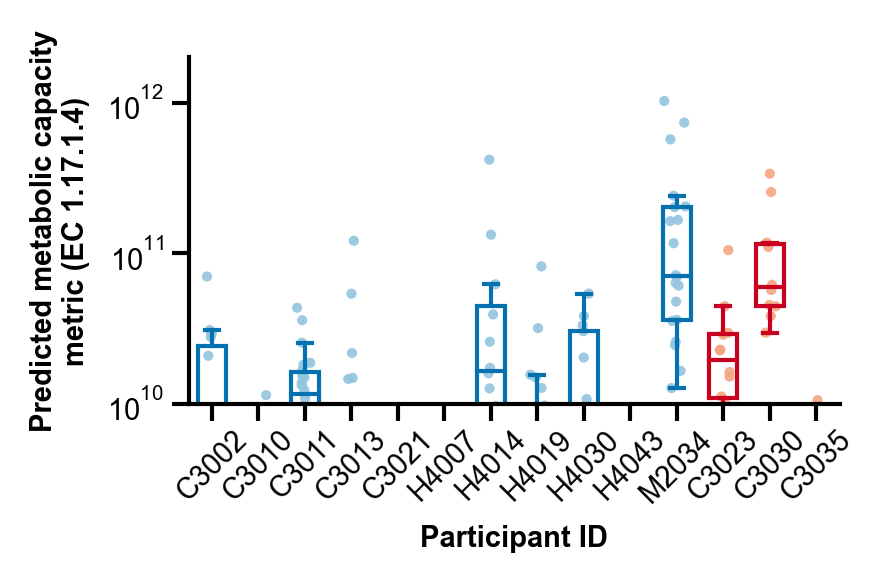

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

peopleID_list = ['C3002','C3010','C3011','C3013','C3021','H4007','H4014','H4019',
                 'H4030','H4043','M2034',
                 'C3023','C3030','C3035',
                 ]

height_data_single = {
    'Streptococcaceae': 3.1,
    'Turicibacteraceae': 3.1,
    'Enterobacteriaceae': 3.1,
    'Alcaligenaceae': 3.4,
    'Veillonellaceae': 3.8,
    'Peptostreptococcaceae': 4.1,
    'Porphyromonadaceae': 4.2,
    'Erysipelotrichaceae': 4.5,
    'Clostridiaceae': 4.5,
    'Bifidobacteriaceae': 5.0,
    'Rikenellaceae': 5.3,
    'Bacteroidaceae': 10.0,
    'Ruminococcaceae': 32.0,
    'Lachnospiraceae': 34.0
}
result ={}
for peopleID in peopleID_list:
    result[peopleID] = [] 
    # print('========', peopleID, '========')
    sampleID_list = get_sampleID_by_peopleID(peopleID, IBDMDB_data)
    all_data = {}
    key_counter = Counter()

    for sampleID in sampleID_list:
        abund_dict = get_sampleID_abundance(sampleID, HGM_data, HGM_data_levellist)
        score = calculate_sampleID_score(height_data_single.keys(), abund_dict, enzyme_counts_dict)
        # print(peopleID,sampleID,score,abund_dict)
        result[peopleID].append(score)
        
import matplotlib.pyplot as plt
import numpy as np

# ===== 数据 =====
data = result

people_ids = list(data.keys())      # 横坐标标签
result_value = list(data.values())        # 每个样本的数值列表
positions = np.arange(len(result_value)) + 0.5  # 箱子位置
# ===== 画布 & 样式 =====
plt.figure(figsize=(2.8, 1.5), dpi=300)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)

# ===== 调色板 =====
colors = ['#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', 
                '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#0571b0', '#ca0020', '#ca0020', '#ca0020']  # 可扩展调色板
group_colors = ['#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de', 
                '#92c5de', '#92c5de', '#92c5de', '#92c5de', '#92c5de',  '#f4a582', '#f4a582', '#f4a582']

# ===== 绘制箱线图 =====
box = plt.boxplot(result_value, positions=positions, widths=0.6,
                  patch_artist=True, showfliers=False)

# ===== box =====
for i, patch in enumerate(box['boxes']):
    color = colors[i]
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(1)

# ===== whiskers =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['whiskers'][2*i].set_color(color)
    box['whiskers'][2*i+1].set_color(color)
    box['whiskers'][2*i].set_linewidth(1)
    box['whiskers'][2*i+1].set_linewidth(1)

# ===== caps =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['caps'][2*i].set_color(color)
    box['caps'][2*i+1].set_color(color)
    box['caps'][2*i].set_linewidth(1)
    box['caps'][2*i+1].set_linewidth(1)

# ===== median =====（每组1条）
for i, median in enumerate(box['medians']):
    color = colors[i]
    median.set_color(color)
    median.set_linewidth(1)

# ===== 绘制散点（stripplot效果） =====
for i, group in enumerate(result_value):
    x_jittered = positions[i] + np.random.normal(0, 0.08, size=len(group))
    plt.scatter(x_jittered, group,
                color=group_colors[i % len(group_colors)],
                edgecolors='none', s=6, zorder=-3, alpha=0.9)
# y轴对数
plt.yscale("log")
# ===== 坐标轴 =====
plt.xticks(positions, people_ids, fontsize=7, rotation=45)
plt.xlabel("Participant ID", fontsize=7, fontweight='bold')
plt.ylabel("Predicted metabolic capacity\nmetric (EC 1.17.1.4)", fontsize=7, fontweight='bold')
plt.tick_params(axis='y', direction='out', width=1, which='major', length=4, pad=2)
plt.tick_params(axis='y', which='minor', left=False)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)
plt.ylim(1e10, 2e12)
plt.show()


Mann-Whitney U test p-value: 3.3176e-02


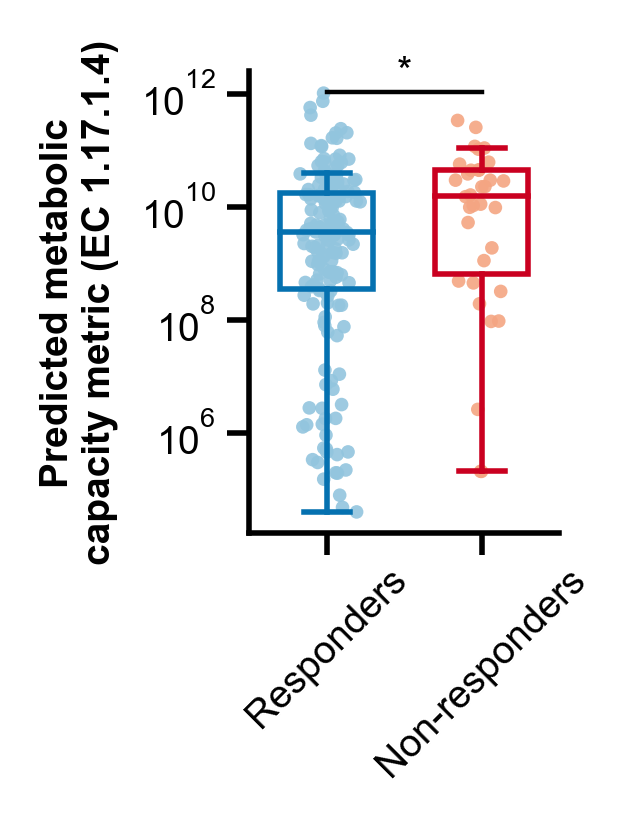

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu  # 也可用 ttest_ind

# ===== 数据 =====
data = result  # 原始 result = {peopleID: [scores]}
people_ids = list(data.keys())
values = list(data.values())

# 合并为两组
group1 = [score for scores in values[:11] for score in scores]  # 前13个合并
group1.remove(min(group1))  # 移除最小值
group2 = [score for scores in values[11:] for score in scores]  # 后5个合并

merged_data = [group1, group2]
group_labels = ["Responders", "Non-responders"]

positions = np.arange(len(merged_data)) + 0.5  # 两个箱子位置

# ===== 统计检验 =====
stat, pval = mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Mann-Whitney U test p-value: {pval:.4e}")
      
# ===== 画布 & 样式 =====
plt.figure(figsize=(1, 1.5), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)

# ===== 调色板 =====
colors = ['#0571b0', '#ca0020']                # 箱体透明
group_colors = ['#92c5de', '#f4a582']    # 散点颜色

# ===== 绘制箱线图 =====
box = plt.boxplot(merged_data, positions=positions, widths=0.6,
                  patch_artist=True, showfliers=False)

# ===== box =====
for i, patch in enumerate(box['boxes']):
    color = colors[i]
    patch.set_facecolor('none')
    patch.set_edgecolor(color)
    patch.set_linewidth(1)

# ===== whiskers =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['whiskers'][2*i].set_color(color)
    box['whiskers'][2*i+1].set_color(color)
    box['whiskers'][2*i].set_linewidth(1)
    box['whiskers'][2*i+1].set_linewidth(1)

# ===== caps =====（每组2条）
for i in range(len(box['boxes'])):
    color = colors[i]
    box['caps'][2*i].set_color(color)
    box['caps'][2*i+1].set_color(color)
    box['caps'][2*i].set_linewidth(1)
    box['caps'][2*i+1].set_linewidth(1)

# ===== median =====（每组1条）
for i, median in enumerate(box['medians']):
    color = colors[i]
    median.set_color(color)
    median.set_linewidth(1)

# # ===== 绘制散点（stripplot效果） =====
# for i, group in enumerate(merged_data):
#     x_jittered = positions[i] + np.random.normal(0, 0.08, size=len(group))
#     plt.scatter(x_jittered, group,
#                 color=group_colors[i], edgecolors='none',
#                 s=6, zorder=-3, alpha=0.9)
threshold = 0

for i, group in enumerate(merged_data):
    # 只用于绘图，不改变原始 group
    group_plot = [x for x in group if x >= threshold]

    x_jittered = positions[i] + np.random.normal(
        0, 0.08, size=len(group_plot)
    )

    plt.scatter(
        x_jittered,
        group_plot,
        color=group_colors[i],
        edgecolors='none',
        s=6,
        zorder=-3,
        alpha=0.9
    )
    
# ===== 显著性标记 =====
y_max = max(max(group1), max(group2))
line_y = y_max * 1.05
plt.plot([positions[0], positions[1]], [line_y+100000, line_y+100000], color='black', linewidth=0.8)
plt.text((positions[0]+positions[1])/2, line_y*1.01,
         f"p = {pval:.2e}" if pval>=0.05 else "*",
         ha='center', va='bottom', fontsize=7)
# y轴对数
plt.yscale("log")
# ===== 坐标轴 =====
plt.xticks(positions, group_labels, fontsize=7, rotation=45)
plt.ylabel("Predicted metabolic\ncapacity metric (EC 1.17.1.4)", fontsize=7, fontweight='bold')
plt.tick_params(axis='y', direction='out', width=1, which='major', length=4, pad=2)
plt.tick_params(axis='y', which='minor', left=False)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)
# plt.ylim(1e6, 2e12)

plt.savefig('../../Figure/Figure-2f.pdf', dpi=400)
plt.show()